In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'
import sys
project_root = './vhseek'
if project_root not in sys.path:
    sys.path.append(project_root)
from vhseek.vhseek_util.statistics_util import analyze_and_visualize
from vhseek.vhseek_util.util import load_embeddings, merge_embedding

# Quick Start

## VHSeek

In [2]:
!python ./vhseek/vhseek_test.py \
-m 'example/model/vhseek' \
-ep 'example/data/embedding/virus.pkl' \
-lip 'example/data/util/index' \
-ltp 'example/data/util/taxonomy' \
-tip 'example/data/util/index' \
-th 0.835 \
-op "example/result/quick_start"

[I 251015 08:16:19 vhseek_test:225] # Testing VHSeek
      model_path      = example/model/vhseek
      embedding_path  = example/data/embedding/virus.pkl
      output_path     = example/result/quick_start
      top             = 10
      threshold       = 0.835
      With embedding  = False
    
[I 251015 08:16:19 util:117] Embeddings Loaded from example/data/embedding/virus.pkl.
[I 251015 08:16:19 vhseek_test:71] # Label size:          7463
[I 251015 08:16:19 vhseek_test:72] # Label-to-taxonomy:   7463
[I 251015 08:16:19 vhseek_test:73] # Taxonomy index size: 7463
[I 251015 08:16:20 vhseek_test:84] Using CUDA for prediction.
[I 251015 08:16:21 vhseek_test:37] PyTorch model loaded successfully.
[I 251015 08:16:21 vhseek_test:118] Applying confidence threshold > 0.835
[I 251015 08:16:21 vhseek_test:168] Virus-level probabilities saved to example/result/quick_start/vhseek_probability
[I 251015 08:16:21 vhseek_test:181] Transferred taxonomy labels saved to example/result/quick_start/vhse

## Probability prediction result

In [3]:
!cat example/result/quick_start/vhseek_label_transfer

[Escherichia phage HeinrichReichert][species]
Escherichia coli	0.963
[Escherichia phage HeinrichReichert][genus]
Escherichia	0.995
[Escherichia phage HeinrichReichert][family]
Enterobacteriaceae	1.000
[Escherichia phage HeinrichReichert][order]
Enterobacterales	1.000
[Escherichia phage HeinrichReichert][class]
Gammaproteobacteria	1.000
[Escherichia phage HeinrichReichert][phylum]
Pseudomonadota	1.000
[Lake Victoria marburgvirus - DRC1999][species]
Rousettus aegyptiacus	0.984
Homo sapiens	0.935
[Lake Victoria marburgvirus - DRC1999][genus]
Rousettus	0.984
Homo	0.936
[Lake Victoria marburgvirus - DRC1999][family]
Pteropodidae	0.984
Hominidae	0.936
[Lake Victoria marburgvirus - DRC1999][order]
Primates	0.989
Chiroptera	0.984
[Lake Victoria marburgvirus - DRC1999][class]
Mammalia	0.999
[Lake Victoria marburgvirus - DRC1999][phylum]
Chordata	1.000
[Norovirus Hu/GII.4/Hong Kong/CUHK6080/2012/CHN][species]
Homo sapiens	1.000
[Norovirus Hu/GII.4/Hong Kong/CUHK6080/2012/CHN][genus]
Homo	1.000
[

## Taxonomy Result

Virus: Escherichia phage HeinrichReichert
Deepest level with data: species
Top host: Escherichia coli (score = 0.963)
Taxonomy:
  infraspecies: _
  species: Escherichia coli
  genus: Escherichia
  family: Enterobacteriaceae
  order: Enterobacterales
  class: Gammaproteobacteria
  phylum: Pseudomonadota



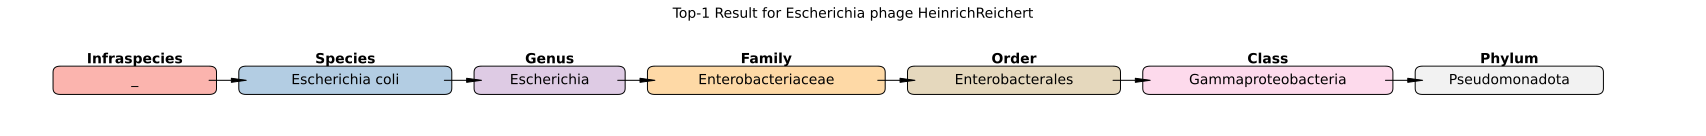

Virus: Lake Victoria marburgvirus - DRC1999
Deepest level with data: species
Top host: Rousettus aegyptiacus (score = 0.984)
Taxonomy:
  infraspecies: _
  species: Rousettus aegyptiacus
  genus: Rousettus
  family: Pteropodidae
  order: Chiroptera
  class: Mammalia
  phylum: Chordata



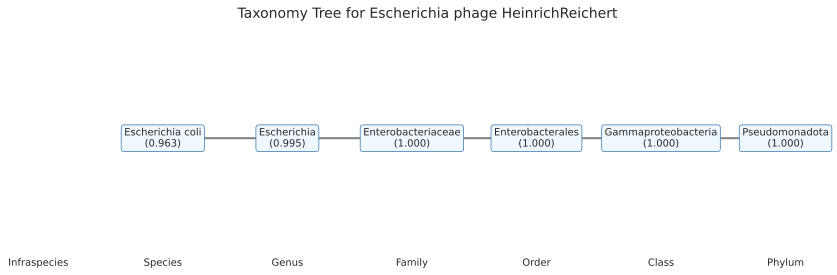

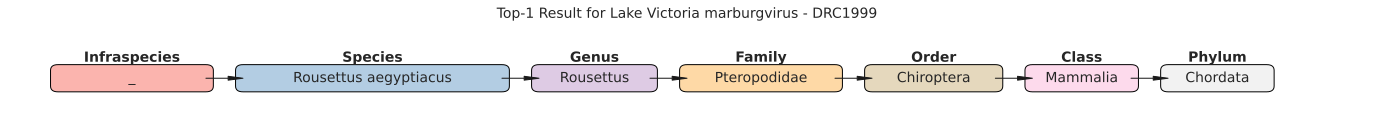

Virus: Norovirus Hu/GII.4/Hong Kong/CUHK6080/2012/CHN
Deepest level with data: species
Top host: Homo sapiens (score = 1.0)
Taxonomy:
  infraspecies: _
  species: Homo sapiens
  genus: Homo
  family: Hominidae
  order: Primates
  class: Mammalia
  phylum: Chordata



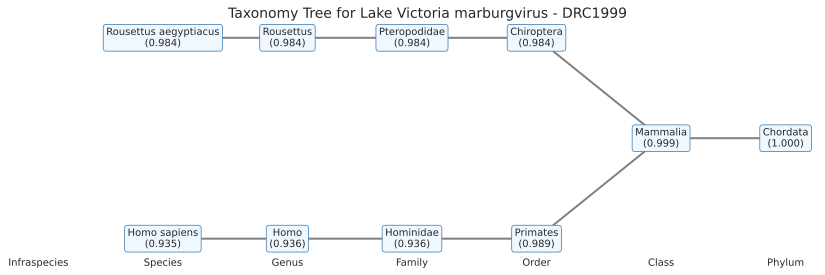

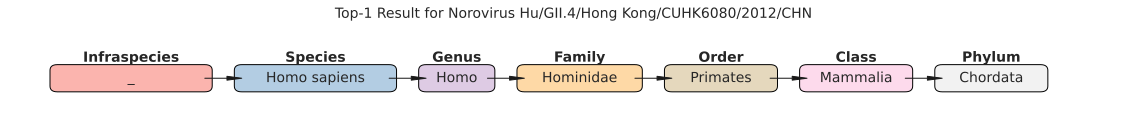

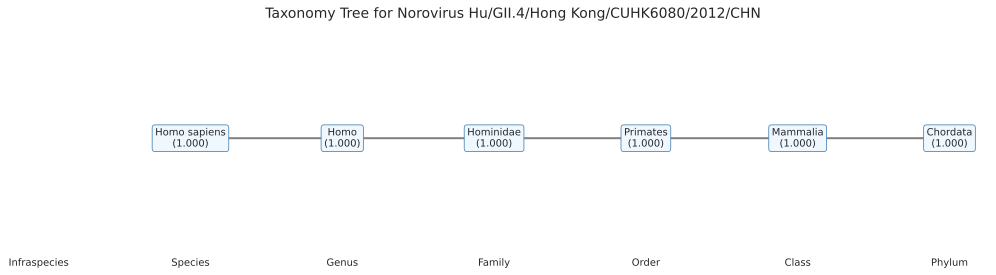

In [4]:
prediction_file = "example/result/quick_start/vhseek_label_transfer"
taxonomy_file = "example/data/util/taxonomy"

analyze_and_visualize(prediction_file, taxonomy_file)

# Custom Sequence Data

## Embedding Generation

In [3]:
# AIDO-300M
!python vhseek/aido_embedding_generate.py \
-f 'example/data/sequence/virus_genome.fasta' \
-ve 'example/data/embedding/virus_aido_300.pkl' \
#--nogpu

[I 251201 21:53:15 aido_embedding_generate:55] Loaded 3 virus genomes from example/data/sequence/virus_genome.fasta
[I 251201 21:53:15 aido_embedding_generate:64] Total chunks to embed: 42
[I 251201 21:53:15 aido_embedding_generate:67] Loading aido_300M backbone …
/opt/conda/envs/vhseek/lib/python3.12/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
You didn't set a max_length for the data in the downstream task
[I 251201 21:53:26 aido_embedding_generate:96] Processed 42/42 chunks
[I 251201 21:53:26 aido_embedding_generate:102] Aggregated embeddings for 3 viruses.
[I 251201 21:53:26 aido_embedding_generate:108] Saved to example/data/embedding/virus_aido_300.pkl
[I 251201 21:53:26 aido_embedding_generate:164] Done in 10.9s


In [4]:
# ESM2-650M
!python vhseek/esm_embedding_generate.py \
-f 'example/data/sequence/virus_protein.fasta' \
-pe 'example/data/embedding/virusprotein_esm2_650.pkl' \
-ve 'example/data/embedding/virus_esm2_650.pkl' \
#--nogpu

[I 251201 21:55:32 esm_embedding_generate:18] Loaded default esm2_t33_650M_UR50D model.
Transferred model to GPU(s): [0, 1, 2, 3, 4, 5, 6, 7]
Read example/data/sequence/virus_protein.fasta with 235 sequences
Processing 1/3 batches (199 sequences)
Get embedding from layer 33
Processing 3/3 batches (2 sequences)
Get embedding from layer 33
[I 251201 21:55:41 util:117] Embeddings Loaded from example/data/embedding/virusprotein_esm2_650.pkl.
[I 251201 21:55:41 esm_embedding_generate:155] Computed mean embeddings for 3 viruses.
[I 251201 21:55:41 esm_embedding_generate:162] Total number of virus proteins originally: 235
[I 251201 21:55:41 esm_embedding_generate:163] Total number of virus proteins collected: 235
[I 251201 21:55:41 esm_embedding_generate:164] Total number of viruses with computed embeddings: 3
[I 251201 21:55:41 esm_embedding_generate:165] Done in 14.9s


In [5]:
# Embedding Merge
aido_file = "example/data/embedding/virus_aido_300.pkl"
esm2_file = "example/data/embedding/virus_esm2_650.pkl"
output_file = "example/data/embedding/virus.pkl"
merge_embedding(aido_file, esm2_file, output_file) # Do not change the order of two embeddings

[I 251201 21:57:39 util:117] Embeddings Loaded from example/data/embedding/virus_aido_300.pkl.
[I 251201 21:57:39 util:117] Embeddings Loaded from example/data/embedding/virus_esm2_650.pkl.
[I 251201 21:57:39 util:166] Merged embeddings saved to example/data/embedding/virus.pkl.


Total merged embeddings: 3
Shape of merged vector for 'Escherichia phage HeinrichReichert': torch.Size([2304])


In [6]:
# Embedding Dimension print
virus_genome_embedding = load_embeddings("example/data/embedding/virus_aido_300.pkl")
print(len(virus_genome_embedding))
print(virus_genome_embedding['Norovirus Hu/GII.4/Hong Kong/CUHK6080/2012/CHN'].shape)

virus_protein_embedding = load_embeddings("example/data/embedding/virus_esm2_650.pkl")
print(len(virus_protein_embedding))
print(virus_protein_embedding['Norovirus Hu/GII.4/Hong Kong/CUHK6080/2012/CHN'].shape)

virus_genome_embedding = load_embeddings("example/data/embedding/virus.pkl")
print(len(virus_genome_embedding))
print(virus_genome_embedding['Norovirus Hu/GII.4/Hong Kong/CUHK6080/2012/CHN'].shape)

[I 251201 21:57:47 util:117] Embeddings Loaded from example/data/embedding/virus_aido_300.pkl.
[I 251201 21:57:47 util:117] Embeddings Loaded from example/data/embedding/virus_esm2_650.pkl.
[I 251201 21:57:47 util:117] Embeddings Loaded from example/data/embedding/virus.pkl.


3
torch.Size([1024])
3
torch.Size([1280])
3
torch.Size([2304])


## VHSeek (DNA & Protein)

In [7]:
!python ./vhseek/vhseek_test.py \
-m 'example/model/vhseek' \
-ep 'example/data/embedding/virus.pkl' \
-lip 'example/data/util/index' \
-ltp 'example/data/util/taxonomy' \
-tip 'example/data/util/index' \
-op "example/result"

[I 251201 21:58:12 vhseek_test:225] # Testing VHSeek
      model_path      = example/model/vhseek
      embedding_path  = example/data/embedding/virus.pkl
      output_path     = example/result
      top             = 10
      threshold       = None
      With embedding  = False
    
[I 251201 21:58:12 util:117] Embeddings Loaded from example/data/embedding/virus.pkl.
[I 251201 21:58:12 vhseek_test:71] # Label size:          7463
[I 251201 21:58:12 vhseek_test:72] # Label-to-taxonomy:   7463
[I 251201 21:58:12 vhseek_test:73] # Taxonomy index size: 7463
[I 251201 21:58:15 vhseek_test:84] Using CUDA for prediction.
[I 251201 21:58:15 vhseek_test:37] PyTorch model loaded successfully.
[I 251201 21:58:16 vhseek_test:168] Virus-level probabilities saved to example/result/vhseek_probability
[I 251201 21:58:16 vhseek_test:181] Transferred taxonomy labels saved to example/result/vhseek_label_transfer


In [8]:
!cat example/result/vhseek_label_transfer

[Escherichia phage HeinrichReichert][infraspecies]
Escherichia coli K-12	0.698
Escherichia coli O177	0.062
Escherichia coli O157:H7	0.030
Escherichia coli str. K-12 substr. MG1655	0.018
[Escherichia phage HeinrichReichert][species]
Escherichia coli	0.963
[Escherichia phage HeinrichReichert][genus]
Escherichia	0.995
[Escherichia phage HeinrichReichert][family]
Enterobacteriaceae	1.000
[Escherichia phage HeinrichReichert][order]
Enterobacterales	1.000
[Escherichia phage HeinrichReichert][class]
Gammaproteobacteria	1.000
[Escherichia phage HeinrichReichert][phylum]
Pseudomonadota	1.000
[Lake Victoria marburgvirus - DRC1999][species]
Rousettus aegyptiacus	0.984
Homo sapiens	0.935
[Lake Victoria marburgvirus - DRC1999][genus]
Rousettus	0.984
Homo	0.936
[Lake Victoria marburgvirus - DRC1999][family]
Pteropodidae	0.984
Hominidae	0.936
[Lake Victoria marburgvirus - DRC1999][order]
Primates	0.989
Chiroptera	0.984
[Lake Victoria marburgvirus - DRC1999][class]
Mammalia	0.999
[Lake Victoria marbur

Virus: Escherichia phage HeinrichReichert
Deepest level with data: infraspecies
Top host: Escherichia coli K-12 (score = 0.698)
Taxonomy:
  infraspecies: Escherichia coli K-12
  species: Escherichia coli
  genus: Escherichia
  family: Enterobacteriaceae
  order: Enterobacterales
  class: Gammaproteobacteria
  phylum: Pseudomonadota



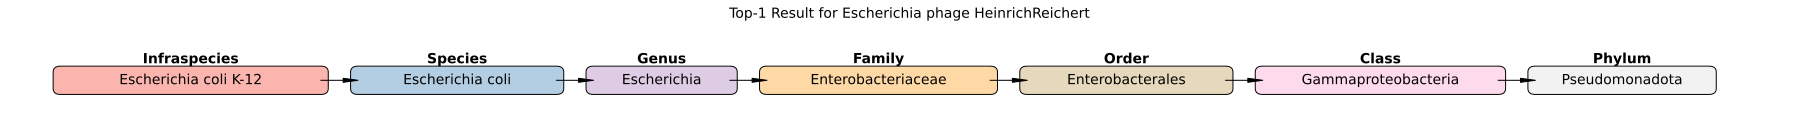

Virus: Lake Victoria marburgvirus - DRC1999
Deepest level with data: species
Top host: Rousettus aegyptiacus (score = 0.984)
Taxonomy:
  infraspecies: _
  species: Rousettus aegyptiacus
  genus: Rousettus
  family: Pteropodidae
  order: Chiroptera
  class: Mammalia
  phylum: Chordata



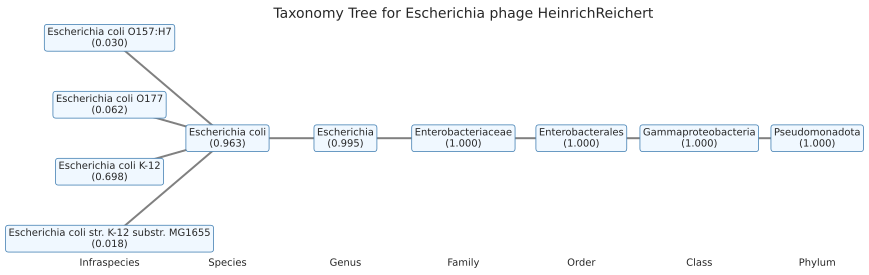

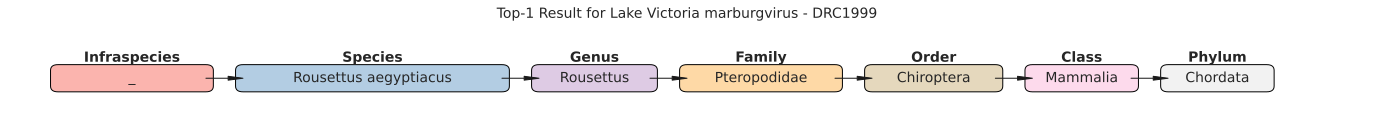

Virus: Norovirus Hu/GII.4/Hong Kong/CUHK6080/2012/CHN
Deepest level with data: species
Top host: Homo sapiens (score = 1.0)
Taxonomy:
  infraspecies: _
  species: Homo sapiens
  genus: Homo
  family: Hominidae
  order: Primates
  class: Mammalia
  phylum: Chordata



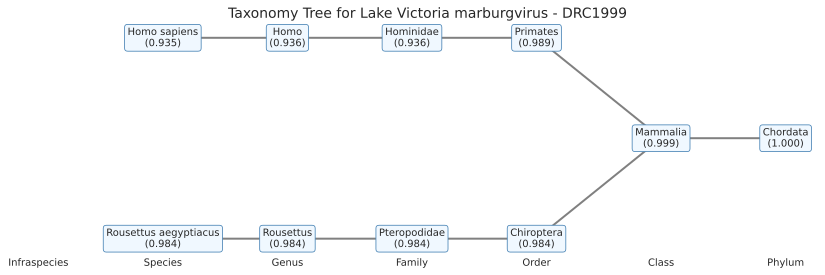

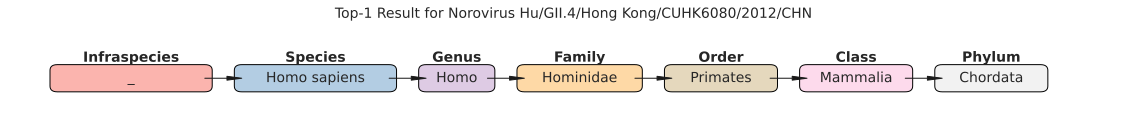

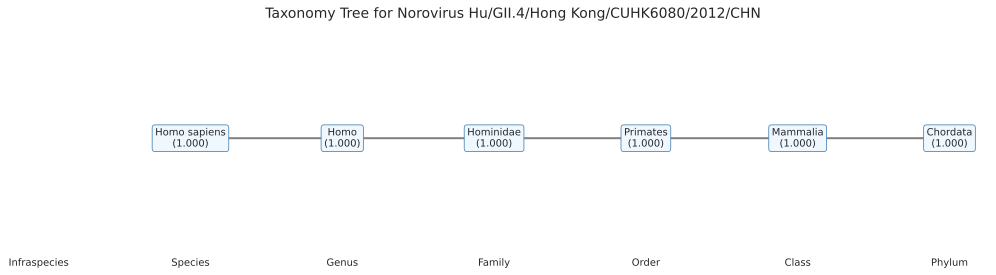

In [9]:
prediction_file = "example/result/vhseek_label_transfer"
taxonomy_file = "vhseek_data/data/util/host_label/label_transfer/taxonomy"

analyze_and_visualize(prediction_file, taxonomy_file)

## VHSeek (DNA)

In [10]:
!python ./vhseek/vhseek_test.py \
-m 'example/model/vhseek_aido_300' \
-ep 'example/data/embedding/virus_aido_300.pkl' \
-lip 'example/data/util/index' \
-ltp 'example/data/util/taxonomy' \
-tip 'example/data/util/index' \
-op "example/result"

[I 251201 21:58:38 vhseek_test:225] # Testing VHSeek
      model_path      = example/model/vhseek_aido_300
      embedding_path  = example/data/embedding/virus_aido_300.pkl
      output_path     = example/result
      top             = 10
      threshold       = None
      With embedding  = False
    
[I 251201 21:58:38 util:117] Embeddings Loaded from example/data/embedding/virus_aido_300.pkl.
[I 251201 21:58:38 vhseek_test:71] # Label size:          7463
[I 251201 21:58:38 vhseek_test:72] # Label-to-taxonomy:   7463
[I 251201 21:58:38 vhseek_test:73] # Taxonomy index size: 7463
[I 251201 21:58:40 vhseek_test:84] Using CUDA for prediction.
[I 251201 21:58:41 vhseek_test:37] PyTorch model loaded successfully.
[I 251201 21:58:41 vhseek_test:168] Virus-level probabilities saved to example/result/vhseek_aido_300_probability
[I 251201 21:58:41 vhseek_test:181] Transferred taxonomy labels saved to example/result/vhseek_aido_300_label_transfer


In [11]:
!cat example/result/vhseek_aido_300_label_transfer

[Escherichia phage HeinrichReichert][infraspecies]
Escherichia coli K-12	0.750
Escherichia coli O177	0.063
Escherichia coli O157:H7	0.024
Escherichia coli str. K-12 substr. MG1655	0.020
[Escherichia phage HeinrichReichert][species]
Escherichia coli	0.960
[Escherichia phage HeinrichReichert][genus]
Escherichia	0.995
[Escherichia phage HeinrichReichert][family]
Enterobacteriaceae	0.998
[Escherichia phage HeinrichReichert][order]
Enterobacterales	1.000
[Escherichia phage HeinrichReichert][class]
Gammaproteobacteria	1.000
[Escherichia phage HeinrichReichert][phylum]
Pseudomonadota	1.000
[Norovirus Hu/GII.4/Hong Kong/CUHK6080/2012/CHN][species]
Homo sapiens	1.000
[Norovirus Hu/GII.4/Hong Kong/CUHK6080/2012/CHN][genus]
Homo	1.000
[Norovirus Hu/GII.4/Hong Kong/CUHK6080/2012/CHN][family]
Hominidae	1.000
[Norovirus Hu/GII.4/Hong Kong/CUHK6080/2012/CHN][order]
Primates	1.000
[Norovirus Hu/GII.4/Hong Kong/CUHK6080/2012/CHN][class]
Mammalia	1.000
[Norovirus Hu/GII.4/Hong Kong/CUHK6080/2012/CHN][ph

Virus: Escherichia phage HeinrichReichert
Deepest level with data: infraspecies
Top host: Escherichia coli K-12 (score = 0.75)
Taxonomy:
  infraspecies: Escherichia coli K-12
  species: Escherichia coli
  genus: Escherichia
  family: Enterobacteriaceae
  order: Enterobacterales
  class: Gammaproteobacteria
  phylum: Pseudomonadota



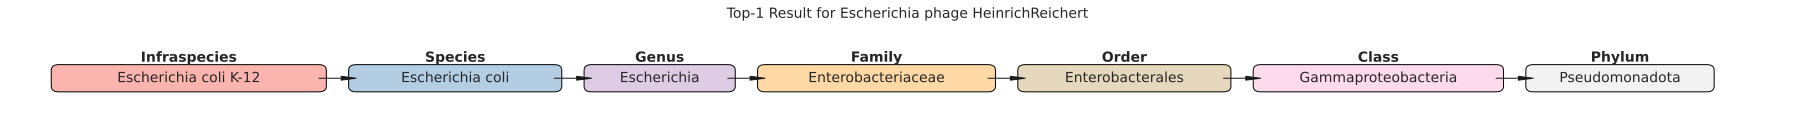

Virus: Norovirus Hu/GII.4/Hong Kong/CUHK6080/2012/CHN
Deepest level with data: species
Top host: Homo sapiens (score = 1.0)
Taxonomy:
  infraspecies: _
  species: Homo sapiens
  genus: Homo
  family: Hominidae
  order: Primates
  class: Mammalia
  phylum: Chordata



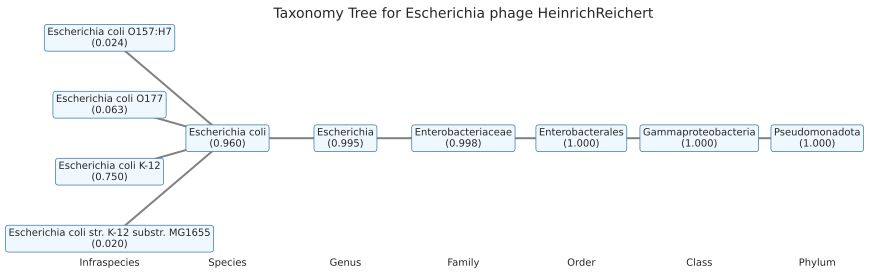

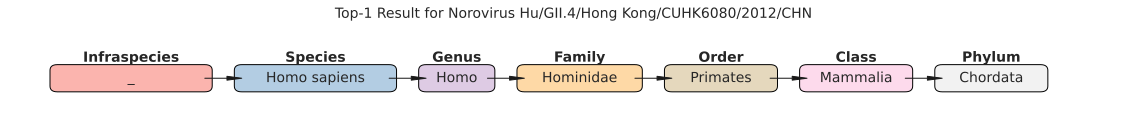

Virus: Lake Victoria marburgvirus - DRC1999
Deepest level with data: species
Top host: Rousettus aegyptiacus (score = 0.992)
Taxonomy:
  infraspecies: _
  species: Rousettus aegyptiacus
  genus: Rousettus
  family: Pteropodidae
  order: Chiroptera
  class: Mammalia
  phylum: Chordata



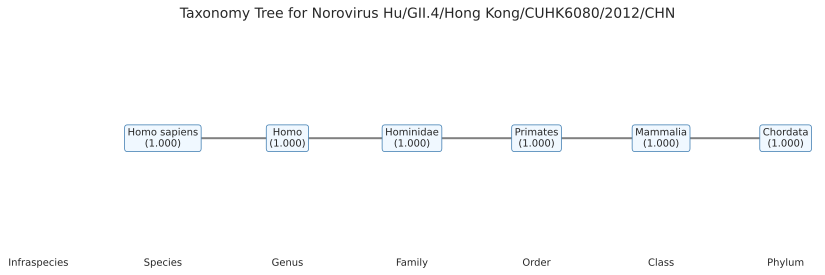

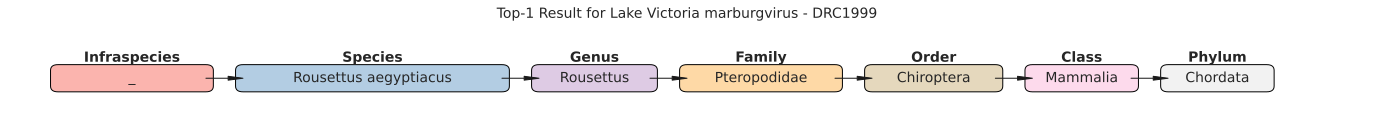

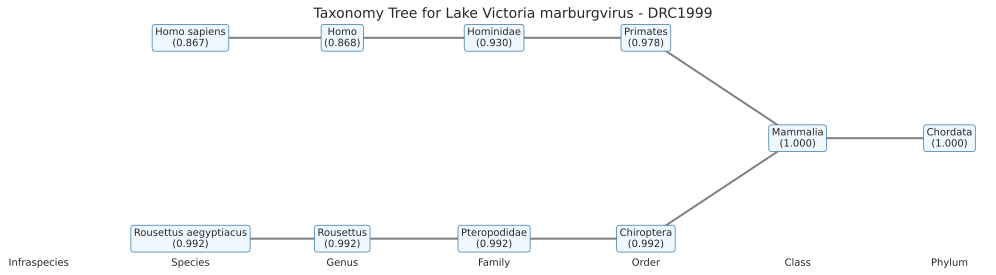

In [12]:
prediction_file = "example/result/vhseek_aido_300_label_transfer"
taxonomy_file = "vhseek_data/data/util/host_label/label_transfer/taxonomy"

analyze_and_visualize(prediction_file, taxonomy_file)

## VHSeek (Protein)

In [13]:
!python ./vhseek/vhseek_test.py \
-m 'example/model/vhseek_esm2_650' \
-ep 'example/data/embedding/virus_esm2_650.pkl' \
-lip 'example/data/util/index' \
-ltp 'example/data/util/taxonomy' \
-tip 'example/data/util/index' \
-op "example/result"

[I 251201 21:59:02 vhseek_test:225] # Testing VHSeek
      model_path      = example/model/vhseek_esm2_650
      embedding_path  = example/data/embedding/virus_esm2_650.pkl
      output_path     = example/result
      top             = 10
      threshold       = None
      With embedding  = False
    
[I 251201 21:59:02 util:117] Embeddings Loaded from example/data/embedding/virus_esm2_650.pkl.
[I 251201 21:59:02 vhseek_test:71] # Label size:          7463
[I 251201 21:59:02 vhseek_test:72] # Label-to-taxonomy:   7463
[I 251201 21:59:02 vhseek_test:73] # Taxonomy index size: 7463
[I 251201 21:59:04 vhseek_test:84] Using CUDA for prediction.
[I 251201 21:59:05 vhseek_test:37] PyTorch model loaded successfully.
[I 251201 21:59:05 vhseek_test:168] Virus-level probabilities saved to example/result/vhseek_esm2_650_probability
[I 251201 21:59:05 vhseek_test:181] Transferred taxonomy labels saved to example/result/vhseek_esm2_650_label_transfer


In [14]:
!cat example/result/vhseek_esm2_650_label_transfer

[Escherichia phage HeinrichReichert][infraspecies]
Escherichia coli K-12	0.393
Escherichia coli O177	0.044
Escherichia coli O157:H7	0.034
Escherichia coli LF82	0.033
[Escherichia phage HeinrichReichert][species]
Escherichia coli	0.841
[Escherichia phage HeinrichReichert][genus]
Escherichia	0.957
[Escherichia phage HeinrichReichert][family]
Enterobacteriaceae	1.000
[Escherichia phage HeinrichReichert][order]
Enterobacterales	1.000
[Escherichia phage HeinrichReichert][class]
Gammaproteobacteria	1.000
[Escherichia phage HeinrichReichert][phylum]
Pseudomonadota	1.000
[Lake Victoria marburgvirus - DRC1999][species]
Homo sapiens	0.733
Rousettus aegyptiacus	0.703
[Lake Victoria marburgvirus - DRC1999][genus]
Homo	0.733
Rousettus	0.703
[Lake Victoria marburgvirus - DRC1999][family]
Hominidae	0.737
Pteropodidae	0.703
[Lake Victoria marburgvirus - DRC1999][order]
Primates	0.960
Chiroptera	0.703
[Lake Victoria marburgvirus - DRC1999][class]
Mammalia	0.993
[Lake Victoria marburgvirus - DRC1999][ph

Virus: Escherichia phage HeinrichReichert
Deepest level with data: infraspecies
Top host: Escherichia coli K-12 (score = 0.393)
Taxonomy:
  infraspecies: Escherichia coli K-12
  species: Escherichia coli
  genus: Escherichia
  family: Enterobacteriaceae
  order: Enterobacterales
  class: Gammaproteobacteria
  phylum: Pseudomonadota



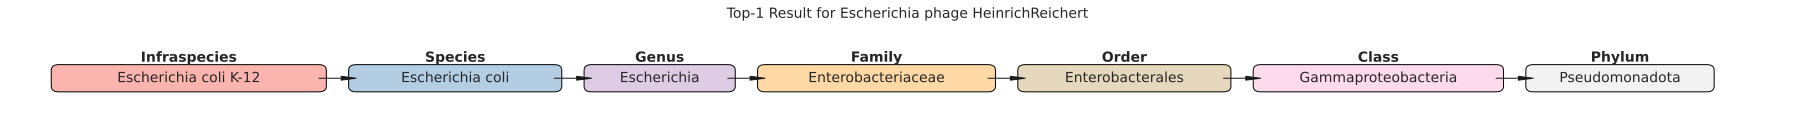

Virus: Lake Victoria marburgvirus - DRC1999
Deepest level with data: species
Top host: Homo sapiens (score = 0.733)
Taxonomy:
  infraspecies: _
  species: Homo sapiens
  genus: Homo
  family: Hominidae
  order: Primates
  class: Mammalia
  phylum: Chordata



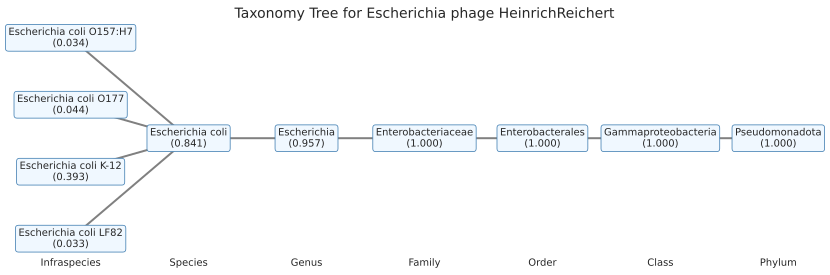

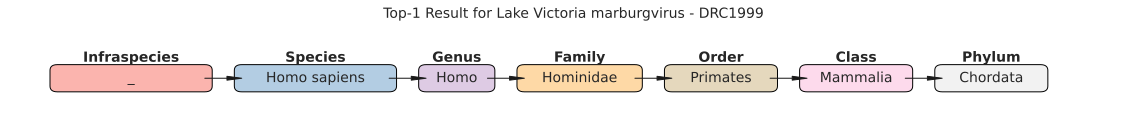

Virus: Norovirus Hu/GII.4/Hong Kong/CUHK6080/2012/CHN
Deepest level with data: species
Top host: Homo sapiens (score = 1.0)
Taxonomy:
  infraspecies: _
  species: Homo sapiens
  genus: Homo
  family: Hominidae
  order: Primates
  class: Mammalia
  phylum: Chordata



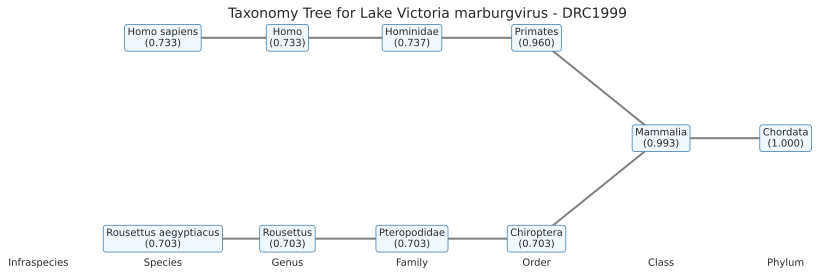

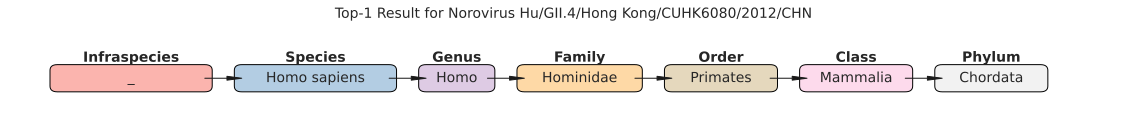

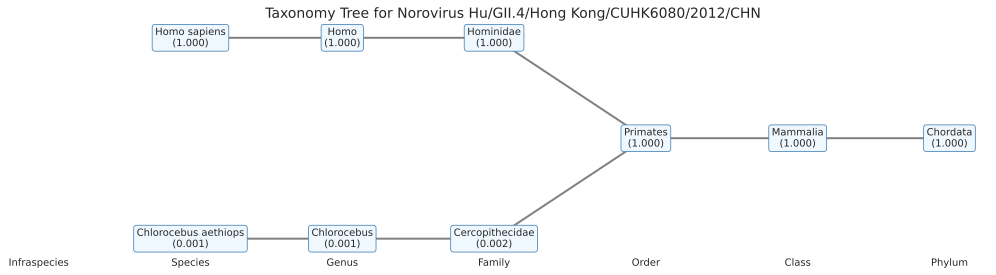

In [15]:
prediction_file = "example/result/vhseek_esm2_650_label_transfer"
taxonomy_file = "vhseek_data/data/util/host_label/label_transfer/taxonomy"

analyze_and_visualize(prediction_file, taxonomy_file)